<a href="https://colab.research.google.com/github/n-manato/audio-data-modeling/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition using the RAVDESS Dataset

## Objective
The goal of this notebook is to classify emotions from speech audio.
Using the RAVDESS dataset, I load speech recordings, visualize sample audio, extract MFCC sequences, and train an LSTM model.
This notebook shows a basic deep learning workflow for speech emotion recognition in Google Colab.

# Import Libraries
In this section, I import the libraries needed for audio processing, visualization, deep learning, and evaluation.

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Load Dataset
In this section, I load the speech audio files from the RAVDESS dataset.
I organize the files and prepare them for emotion classification.

In [11]:
dataset_path = "./Audio_Speech_Actors_01-24"

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Number of audio files:", len(audio_files))
print("First sample file:", os.path.basename(audio_files[0]))

Number of audio files: 1440
First sample file: 03-01-01-01-01-01-01.wav


# Explore Audio
In this section, I visualize sample audio files using waveforms and MFCCs.
This helps me understand the speech signal and time frequency patterns before training the model.

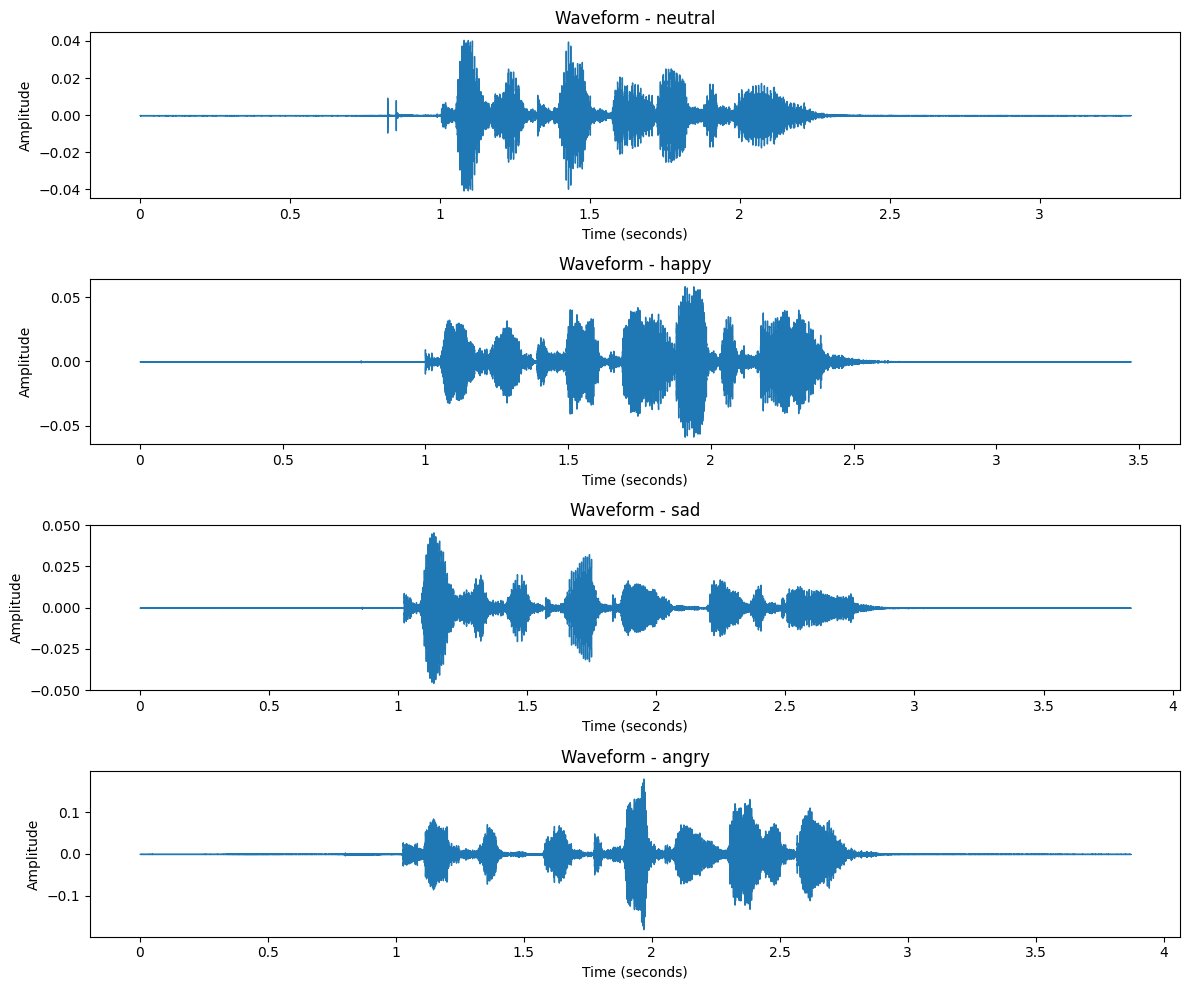

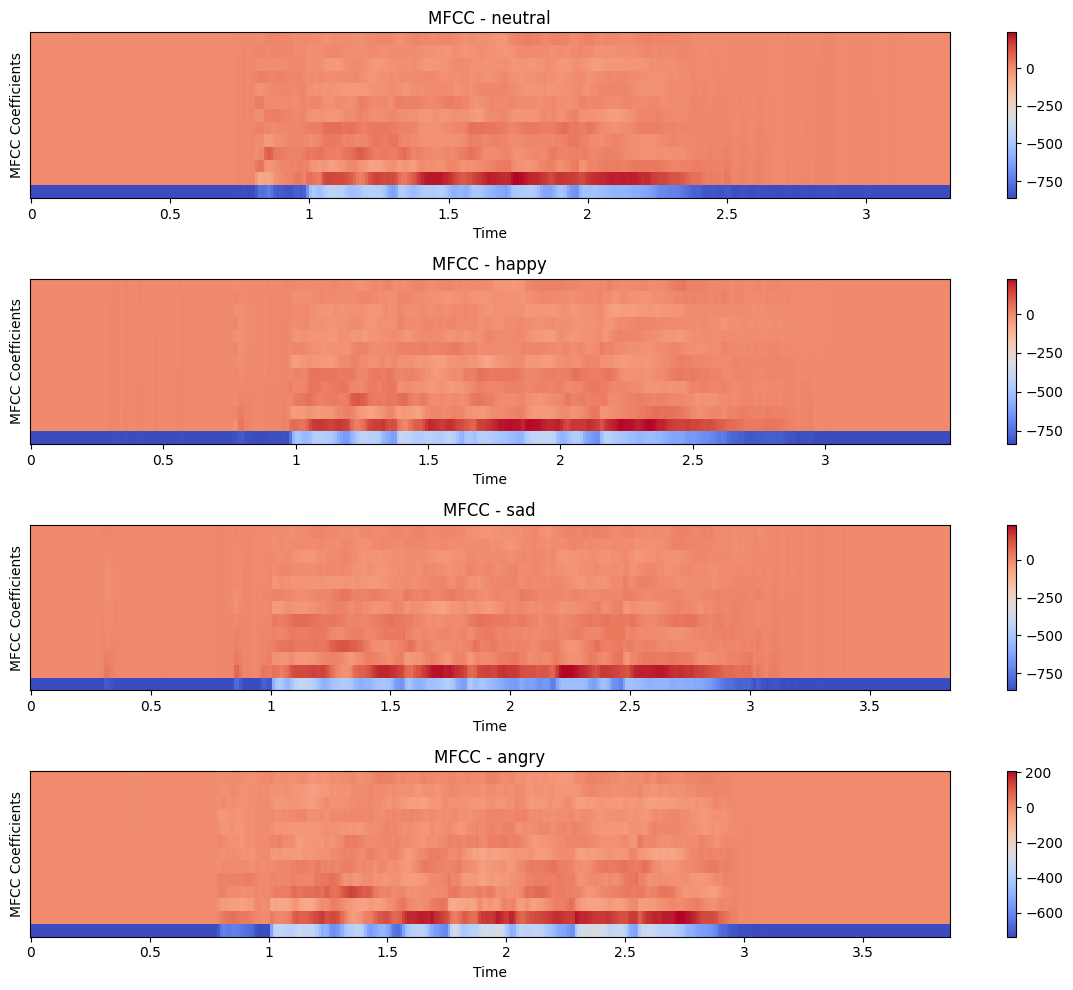

In [12]:
selected_emotions = ["01", "03", "04", "05"]
emotion_order = selected_emotions

sample_by_emotion = {}
for file_path in audio_files:
    file_name = os.path.basename(file_path)
    emotion_code = file_name.split("-")[2]
    if emotion_code in selected_emotions and emotion_code not in sample_by_emotion:
        sample_by_emotion[emotion_code] = file_path

plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    plt.subplot(len(emotion_order), 1, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

    plt.subplot(len(emotion_order), 1, i)
    librosa.display.specshow(mfcc, x_axis="time", sr=sr)
    plt.title(f"MFCC - {emotion_map[emotion_code]}")
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    plt.colorbar()

plt.tight_layout()
plt.show()

The waveform shows where the speech is quiet and where the main voice activity appears.
The MFCC plot shows how the spectral pattern changes over time.
These plots help show how speech structure may differ across emotions.

# Feature Extraction
In this section, I extract features based on **MFCC**.

MFCC represents the short term spectral shape of speech and is widely used in audio classification.
Because LSTM can process time series directly, I keep the MFCC frames as a sequence instead of reducing them to summary statistics.

The extracted MFCC based features are:

- 13 MFCC coefficients per frame
- time ordered sequence of frames

These features are useful because they preserve how the speech signal changes over time.
This is important for emotion recognition, since emotional speech often differs in rhythm, emphasis, and spectral shape.

In [13]:
X_sequences = []
y_labels = []

for file_path in audio_files:
    file_name = os.path.basename(file_path)
    emotion_code = file_name.split("-")[2]

    if emotion_code in selected_emotions:
        signal, sr = librosa.load(file_path, sr=None)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
        mfcc = mfcc.T

        X_sequences.append(mfcc)
        y_labels.append(emotion_map[emotion_code])

print("Number of samples:", len(X_sequences))
print("First sequence shape:", X_sequences[0].shape)

Number of samples: 672
First sequence shape: (310, 13)


# Prepare Data
In this section, I pad the MFCC sequences so they have the same length.
I also encode the emotion labels and split the dataset into training and testing sets.

In [14]:
max_len = max(seq.shape[0] for seq in X_sequences)
X = pad_sequences(X_sequences, maxlen=max_len, dtype="float32", padding="post", truncating="post")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Padded data shape:", X.shape)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Padded data shape: (672, 479, 13)
Training set shape: (537, 479, 13)
Test set shape: (135, 479, 13)


# Model Training
In this section, I build and train an LSTM model.
The model reads the MFCC sequence frame by frame and learns temporal patterns related to emotion.

In [15]:
model = Sequential([
    Masking(mask_value=0.0, input_shape=(X.shape[1], X.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(y_categorical.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\manas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 479, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,180 (86.64 KB)

 Trainable params: 22,180 (86.64 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.2541 - loss: 1.4494 - val_accuracy: 0.3704 - val_loss: 1.3585
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3333 - loss: 1.3815 - val_accuracy: 0.3333 - val_loss: 1.3481
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3380 - loss: 1.3428 - val_accuracy: 0.2778 - val_loss: 1.3316
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3613 - loss: 1.3182 - val_accuracy: 0.3889 - val_loss: 1.3178
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3590 - loss: 1.3410 - val_accuracy: 0.2870 - val_loss: 1.3073
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3823 - loss: 1.3062 - val_accuracy: 0.3519 - val_loss: 1.2891
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.3846 - loss: 1.2804 - val_accuracy: 0.3889 - val_loss: 1.2667
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.4149 - loss: 1.2465 - val_accuracy: 0.4815 - v

# Evaluation
In this section, I evaluate the LSTM model using the test dataset.
I measure accuracy and examine the classification report and confusion matrix.
These results help show how well the model recognizes each emotion.

Test accuracy: 0.5555555820465088
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.74      0.82      0.78        38
       happy       0.47      0.49      0.48        39
     neutral       0.00      0.00      0.00        19
         sad       0.47      0.64      0.54        39

    accuracy                           0.56       135
   macro avg       0.42      0.49      0.45       135
weighted avg       0.48      0.56      0.51       135

Confusion Matrix:
         angry  happy  neutral  sad
angry       31      6        0    1
happy        9     19        0   11
neutral      0      3        0   16
sad          2     12        0   25


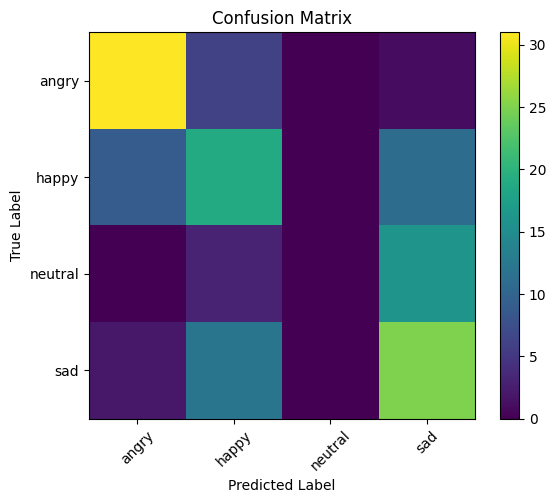

In [17]:
loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_accuracy)

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

print("Confusion Matrix:")
print(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
plt.yticks(tick_marks, label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

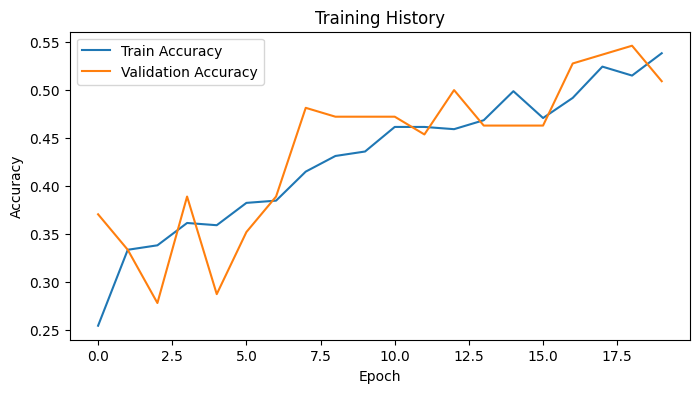

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The accuracy score shows the overall test performance of the LSTM model.
The classification report provides precision, recall, and F1 score for each emotion.
The confusion matrix shows which emotions were predicted correctly and which emotions were confused with each other.
The training history plot shows how the model performance changed across epochs.

# Conclusion
In this notebook, I used MFCC sequences from the RAVDESS dataset to classify emotions with an LSTM model.
Unlike traditional machine learning models that use fixed length summary features, this approach keeps the time order of speech frames.

The results suggest that temporal information in speech can help emotion recognition, although some emotions may still be difficult to separate.
Overall, this project helped me understand a basic deep learning workflow for audio processing, sequence modeling, and emotion classification.